In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import scatter
import os

def weighted_global_mean_pool(x, batch, node_w):
    # node_w: [N] or [N,1]
    if node_w.dim() == 1:
        node_w = node_w.view(-1, 1)
    node_w = node_w.to(x.dtype)

    num = scatter(x * node_w, batch, dim=0, reduce="sum")
    den = scatter(node_w, batch, dim=0, reduce="sum").clamp(min=1e-12)
    return num / den


class WeightedGCN(nn.Module):
    """
    - edge_weight used inside GCNConv message passing
    - node_weights used by scaling node features before each conv (message strength)
    - also uses weighted pooling (optional but consistent)
    """
    def __init__(self, in_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim, add_self_loops=True, normalize=True))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim, add_self_loops=True, normalize=True))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        device = x.device

        # edge weights for message passing
        edge_weight = getattr(data, "edge_weight", None)
        if edge_weight is None:
            raise AttributeError("Graph is missing data.edge_weight")

        # node weights for message passing
        node_w = getattr(data, "node_weights", None)
        if node_w is None:
            raise AttributeError("Graph is missing data.node_weights")

        if isinstance(node_w, list):
            node_w = torch.tensor(node_w, device=x.device)
        node_w = node_w.to(x.device)

        # normalize node weights (helps stability; optional but recommended)
        # avoids huge weights dominating
        node_w = node_w.to(x.dtype)
        node_w = node_w / (node_w.mean().clamp(min=1e-12))

            # --------- NEW: handle missing batch ---------
        if not hasattr(data, "batch") or data.batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
        else:
            batch = data.batch
        # --------------------------------------------

        # message passing
        for conv in self.convs:
            # node_weights affect outgoing messages by scaling node features
            x_in = x * node_w.view(-1, 1)
            x = conv(x_in, edge_index, edge_weight=edge_weight)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # graph embedding (use weighted mean pooling; you can swap to global_mean_pool if you want)
        g = weighted_global_mean_pool(x, batch, node_w)

        logits = self.head(g).view(-1)
        return logits


In [10]:
# ===== Train + Test (no validation / no early-stopping) =====
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader

def auroc_from_probs(probs: torch.Tensor, y_true: torch.Tensor) -> float: 
    y = y_true.numpy().astype(int) 
    if len(set(y.tolist())) < 2: 
        return float("nan") 
    p = probs.numpy() 
    order = np.argsort(p) 
    ranks = np.empty_like(order, dtype=float) 
    ranks[order] = np.arange(len(p)) + 1 
    pos_ranks_sum = ranks[y == 1].sum() 
    n_pos = (y == 1).sum() 
    n_neg = (y == 0).sum() 
    return float((pos_ranks_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)) 

@torch.no_grad() 
def eval_loader(model, loader, device): 
    model.eval() 
    logits_all, y_all = [], [] 
    for batch in loader: 
        batch = batch.to(device) 
        logits = model(batch) 
        logits_all.append(logits.detach().cpu()) 
        y_all.append(batch.y.view(-1).detach().cpu().long()) 
    logits_all = torch.cat(logits_all) 
    y_all = torch.cat(y_all) 
    probs = torch.sigmoid(logits_all) 
    auroc = auroc_from_probs(probs, y_all) 
    return float(auroc), probs, y_all

def stratified_train_test_indices(y, test_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    y = np.array(y, dtype=int)

    idx0 = np.where(y == 0)[0].tolist()
    idx1 = np.where(y == 1)[0].tolist()
    rng.shuffle(idx0); rng.shuffle(idx1)

    n0_test = int(round(len(idx0) * test_frac))
    n1_test = int(round(len(idx1) * test_frac))

    te_idx = idx0[:n0_test] + idx1[:n1_test]
    tr_idx = idx0[n0_test:] + idx1[n1_test:]
    rng.shuffle(te_idx); rng.shuffle(tr_idx)
    return tr_idx, te_idx


@torch.no_grad()
def train_auroc(model, loader, device):
    model.eval()
    logits_all, y_all = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        logits_all.append(logits.detach().cpu())
        y_all.append(batch.y.view(-1).detach().cpu().long())
    logits_all = torch.cat(logits_all)
    y_all = torch.cat(y_all)
    probs = torch.sigmoid(logits_all)
    auroc = auroc_from_probs(probs, y_all)
    return float(auroc)

def train_pick_best_train_auroc_then_test(
    graphs,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=16,
    epochs=200,
    test_frac=0.2,
    seed=0,
    device=None,
    save_path="models/weighted_gcn.pt",
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    torch.manual_seed(seed)
    np.random.seed(seed)

    ys = [int(g.y.view(-1)[0].item()) for g in graphs]
    in_dim = graphs[0].x.size(-1)

    tr_idx, te_idx = stratified_train_test_indices(ys, test_frac=test_frac, seed=seed)
    train_set = [graphs[i] for i in tr_idx]
    test_set  = [graphs[i] for i in te_idx]

    train_loader_shuf = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    train_loader_eval = DataLoader(train_set, batch_size=batch_size, shuffle=False)  # for AUROC calc
    test_loader       = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

    model = WeightedGCN(in_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # class imbalance handling
    y_train = torch.tensor([int(g.y.view(-1)[0].item()) for g in train_set], dtype=torch.long)
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device, dtype=torch.float32)

    best_state = None
    best_train_auroc = -1e9
    best_epoch = 0

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for batch in train_loader_shuf:
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch)
            yb = batch.y.view(-1).float()
            loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
            loss.backward()
            opt.step()
            total_loss += float(loss.item())

        # evaluate AUROC on TRAIN set (no validation)
        tr_auroc = train_auroc(model, train_loader_eval, device)
        if np.isnan(tr_auroc):
            tr_auroc = -1e9

        if tr_auroc > best_train_auroc:
            best_train_auroc = tr_auroc
            best_epoch = ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"epoch {ep:03d} | train_loss={total_loss/len(train_loader_shuf):.4f} | train_auroc={tr_auroc:.3f}")

    # load best-by-train-auroc model
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    print(f"Best TRAIN AUROC: {best_train_auroc:.3f} (epoch {best_epoch})")

    # test once with the selected model
    test_auroc, test_probs, test_y = eval_loader(model, test_loader, device)
    print(f"Test AUROC: {test_auroc:.3f}")

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    torch.save({
        "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "config": {
            "in_dim": int(in_dim),
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "dropout": dropout,
        },
        "best_train_auroc": float(best_train_auroc),
        "best_epoch": int(best_epoch),
        "test_auroc": float(test_auroc),
        "split": {"train_idx": tr_idx, "test_idx": te_idx},
    }, save_path)
    print(f"Saved model to: {save_path}")

    return model, test_probs, test_y, test_auroc


In [11]:
import os
import glob
import torch
from torch_geometric.data import Data

def load_graphs_and_tables(graph_dir: str):
    """
    Loads .pt files saved per patient as a dict with keys:
      - patient_id (str)
      - label (int)
      - graph (torch_geometric.data.Data)
      - data (often pandas.DataFrame)
    Returns:
      graphs: list[Data]
      tables: list[object]
      patient_ids: list[str]
      labels: list[int]
      paths: list[str]
    """
    paths = sorted(glob.glob(os.path.join(graph_dir, "*.pt")))
    if not paths:
        raise FileNotFoundError(f"No .pt files found in: {graph_dir}")

    graphs, tables, patient_ids, labels, used_paths = [], [], [], [], []
    for p in paths:
        obj = torch.load(p, map_location="cpu", weights_only=False)

        if not isinstance(obj, dict):
            raise TypeError(f"{p}: expected dict, got {type(obj)}. Did you rebuild graphs with the new saver?")

        if "graph" not in obj:
            raise KeyError(f"{p}: missing key 'graph' in saved dict. Keys: {list(obj.keys())}")

        graph = obj["graph"]
        table = obj.get("data", None)
        pid = obj.get("patient_id", os.path.splitext(os.path.basename(p))[0])
        lab = obj.get("label", None)

        if not isinstance(graph, Data):
            raise TypeError(f"{p}: obj['graph'] is {type(graph)}, expected torch_geometric.data.Data")

        # ensure graph.y exists and matches label (your trainer expects graph.y)
        if getattr(graph, "y", None) is None:
            if lab is None:
                raise ValueError(f"{p}: graph has no y and dict has no 'label'.")
            graph.y = torch.tensor([int(lab)], dtype=torch.long)

        graphs.append(graph)
        tables.append(table)
        patient_ids.append(pid)
        labels.append(int(graph.y.view(-1)[0].item()))
        used_paths.append(p)

    print(f"Loaded {len(graphs)} patient graphs from {graph_dir}")
    return graphs, tables, patient_ids, labels, used_paths

In [12]:
distance_threshold = 0.08
use_mst = True
enrich = True

graph_path = "/dsi/efroni-lab/sbm/chen2/graphs_600_common/zeros"
graph_dir = f"{graph_path}/{distance_threshold}_{use_mst}_{enrich}"

save_path = f"models/AB_{distance_threshold}_{use_mst}_{enrich}"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

In [13]:
graphs, tables, patient_ids, labels, used_paths = load_graphs_and_tables(graph_dir)

Loaded 83 patient graphs from /dsi/efroni-lab/sbm/chen2/graphs_600_common/zeros/0.08_True_True


In [14]:

model, test_probs, test_y, test_auroc = train_pick_best_train_auroc_then_test(
    graphs,
    seed=42,
    epochs=200,
    batch_size=16,
    lr=1e-3,
    weight_decay=5e-4,
    hidden_dim=16,
    num_layers=1,
    dropout=0.5,
    test_frac=0.25,
    save_path=f"{save_path}/patient_gnn_final.pt",
)

epoch 001 | train_loss=0.8252 | train_auroc=0.753
epoch 002 | train_loss=0.7981 | train_auroc=0.738
epoch 003 | train_loss=0.7835 | train_auroc=0.734
epoch 004 | train_loss=0.8391 | train_auroc=0.733
epoch 005 | train_loss=0.9537 | train_auroc=0.737
epoch 006 | train_loss=0.8866 | train_auroc=0.739
epoch 007 | train_loss=0.8658 | train_auroc=0.748
epoch 008 | train_loss=0.8727 | train_auroc=0.767
epoch 009 | train_loss=0.7800 | train_auroc=0.779
epoch 010 | train_loss=0.7865 | train_auroc=0.772
epoch 011 | train_loss=0.7768 | train_auroc=0.772
epoch 012 | train_loss=0.8018 | train_auroc=0.769
epoch 013 | train_loss=0.7747 | train_auroc=0.772
epoch 014 | train_loss=0.7692 | train_auroc=0.772
epoch 015 | train_loss=0.8448 | train_auroc=0.783
epoch 016 | train_loss=0.8359 | train_auroc=0.806
epoch 017 | train_loss=0.7827 | train_auroc=0.827
epoch 018 | train_loss=0.8339 | train_auroc=0.816
epoch 019 | train_loss=0.8035 | train_auroc=0.809
epoch 020 | train_loss=0.7875 | train_auroc=0.782


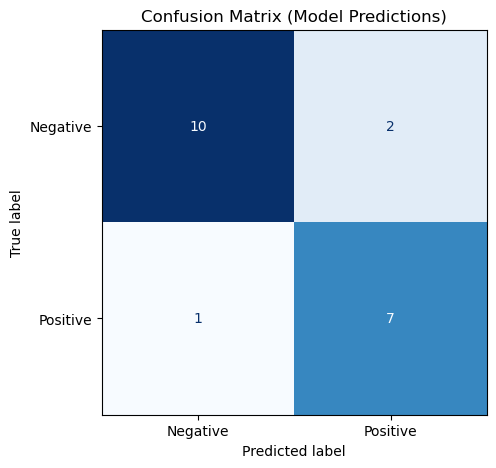

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Use model's predictions on the validation set for the confusion matrix
# Assumes you have val_probs (model probabilities) and val_y (true labels) from eval_loader
# If not, rerun eval_loader(model, val_loader, device) to get them

# Example (uncomment and run if needed):
# val_auroc, val_probs, val_y = eval_loader(model, val_loader, device)

y_true = test_y.numpy()
y_pred = (test_probs.numpy() > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (Model Predictions)")
plt.show()


In [16]:
import torch

def node_weight_saliency(model, data, device, use_abs=True):
    model.eval()
    data = data.to(device)

    # חשוב: להפוך את node_weights לטנסור שמקבל גרדיאנט
    node_w = data.node_weights
    if isinstance(node_w, list):
        node_w = torch.tensor(node_w, device=device)
    else:
        node_w = node_w.to(device)
    node_w = node_w.float().detach().clone().requires_grad_(True)

    # לשים אותו חזרה ב-data (כדי שה-forward ישתמש בזה)
    data.node_weights = node_w

    # forward -> לוגיט (לפני sigmoid)
    logit = model(data)  # shape [batch_graphs] אבל אצלך בד"כ batch=1 כאן
    if logit.numel() != 1:
        # אם יש באץ' של כמה גרפים, אפשר לבחור אינדקס או לסכם
        logit = logit.sum()

    model.zero_grad(set_to_none=True)
    if node_w.grad is not None:
        node_w.grad.zero_()
    logit.backward()

    grad = node_w.grad.detach()                 # [N]
    score = grad * node_w.detach()              # grad*input
    if use_abs:
        score = score.abs()
    return score.detach().cpu()                 # [600]
from torch_geometric.loader import DataLoader

@torch.no_grad()
def get_node_seqs_from_graph(g):
    # node_seqs יכול להיות list[str] או משהו דומה
    return g.node_seqs

def global_importance_gradxinput(model, graphs, device, batch_size=1):
    # מומלץ batch_size=1 בשביל אטריביושן ברור (או תעשה לולאה על graphs)
    scores_sum = None
    n = 0

    for g in graphs:
        s = node_weight_saliency(model, g, device)  # [600]
        if scores_sum is None:
            scores_sum = torch.zeros_like(s)
        scores_sum += s
        n += 1

    mean_score = scores_sum / max(n, 1)
    node_seqs = get_node_seqs_from_graph(graphs[0])
    return mean_score, node_seqs

mean_score, node_seqs = global_importance_gradxinput(model, graphs, device=model.head[0].weight.device)
norm_score = mean_score / mean_score.max()
# norm_score = torch.softmax(mean_score, dim=0)
topk = torch.topk(norm_score, k=30)
for rank, (idx, val) in enumerate(zip(topk.indices.tolist(), topk.values.tolist()), 1):
    print(rank, idx, val, node_seqs[idx])


1 598 1.0 CVVSDRGSTLGRLYF
2 421 0.22392797470092773 CAVMDSNYQLIW
3 483 0.14860370755195618 CAVRDSNYQLIW
4 408 0.08697132021188736 CAVLDSNYQLIW
5 422 0.05664002150297165 CAVMDSSYKLIF
6 114 0.049107931554317474 CADHQNYGGSQGNLIF
7 15 0.043179333209991455 CAAMDSNYQLIW
8 12 0.04282228276133537 CAALDSNYQLIW
9 407 0.042337894439697266 CAVKTSYDKVIF
10 339 0.0418696254491806 CASSRDSQETQYF
11 405 0.036032941192388535 CAVKDSNYQLIW
12 193 0.0350467674434185 CALSAARSSNTGKLIF
13 558 0.03370276466012001 CAVTDSNYQLIW
14 213 0.032872967422008514 CAPMDSNYQLIW
15 474 0.02824133075773716 CAVRDGDYKLSF
16 571 0.022923653945326805 CAVVDSNYQLIW
17 227 0.022665157914161682 CASSFSYEQYF
18 358 0.022558845579624176 CAVDDYKLSF
19 313 0.02174285613000393 CASSLSSYEQYF
20 217 0.02005026862025261 CASASPSSYNEQFF
21 144 0.018766865134239197 CAGMDSNYQLIW
22 32 0.018430734053254128 CAAPNQAGTALIF
23 448 0.01791015826165676 CAVNTGGFKTIF
24 164 0.017371201887726784 CALGEPYNQGGKLIF
25 523 0.0152580039575696 CAVSDSNYQLIW
26 21

In [17]:
output_path = f"{save_path}/model_outputs.pt"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

outputs = {
    "test_auroc": float(test_auroc),
    "test_probs": test_probs.detach().cpu(),
    "test_y": test_y.detach().cpu(),
    "cdr3_importance": {
        "node_seqs": node_seqs,
        "norm_score": norm_score.detach().cpu(),
    },
}

torch.save(outputs, output_path)
print(f"Saved outputs to: {output_path}")

Saved outputs to: models/AB_0.08_True_True/model_outputs.pt


In [ ]:
import pandas as pd

# Create a summary dataframe with test predictions and patient info
results_df = pd.DataFrame({
    'patient_id': patient_ids[-len(test_y):],  # Get last test_set size
    'true_label': test_y.numpy(),
    'predicted_prob': test_probs.numpy(),
    'predicted_label': (test_probs.numpy() > 0.5).astype(int),
})

# Create CDR3 importance dataframe
cdr3_importance_df = pd.DataFrame({
    'cdr3_sequence': node_seqs,
    'importance_score': norm_score.numpy(),
})
cdr3_importance_df = cdr3_importance_df.sort_values('importance_score', ascending=False).reset_index(drop=True)

# Save to CSV files
results_output_path = f"{save_path}/test_predictions.csv"
cdr3_output_path = f"{save_path}/cdr3_importance.csv"

results_df.to_csv(results_output_path, index=False)
cdr3_importance_df.to_csv(cdr3_output_path, index=False)

print(f"Saved test predictions to: {results_output_path}")
print(f"Saved CDR3 importance to: {cdr3_output_path}")
print(f"\nTest AUROC: {test_auroc:.4f}")
print(f"\nTop 10 CDR3 sequences:")
print(cdr3_importance_df.head(10))

Saved test predictions to: models/AB_0.08_True_True/test_predictions.csv
Saved CDR3 importance to: models/AB_0.08_True_True/cdr3_importance.csv

Test AUROC: 0.8854

Top 10 CDR3 sequences:
      cdr3_sequence  importance_score
0   CVVSDRGSTLGRLYF          1.000000
1      CAVMDSNYQLIW          0.223928
2      CAVRDSNYQLIW          0.148604
3      CAVLDSNYQLIW          0.086971
4      CAVMDSSYKLIF          0.056640
5  CADHQNYGGSQGNLIF          0.049108
6      CAAMDSNYQLIW          0.043179
7      CAALDSNYQLIW          0.042822
8      CAVKTSYDKVIF          0.042338
9     CASSRDSQETQYF          0.041870
